In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

import sys
import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = './agrupamento.csv'
df = pd.read_csv(data)

In [4]:
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9
0,1.595552,-4.346674,8.006582,-4.262376,0.385801,4.644062,5.375226,5.277214,-3.128601,2.645725
1,-6.489084,7.012277,-4.749651,4.594856,-0.166381,2.857733,-9.623445,-1.466119,-10.169456,9.144532
2,1.894247,-6.744838,2.825614,-7.331948,0.997029,5.920935,7.417770,4.528579,-1.842886,-1.656199
3,6.415573,-14.342761,3.025061,-7.628352,2.671143,4.845565,6.840920,2.605155,-3.410962,2.590488
4,-4.484811,-1.643745,3.553013,4.078241,-4.403737,1.310735,2.185299,-5.333726,0.946464,-6.721340


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import numpy as np
import matplotlib.pyplot as plt

# Preparar os dados (assumindo que todas as colunas são numéricas)
# Se houver colunas categóricas, você precisará fazer encoding primeiro
X = df.select_dtypes(include=[np.number])

print("Dimensões dos dados:", X.shape)
print("Colunas utilizadas:", X.columns.tolist())

# Padronizar os dados (importante para clustering)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nDados padronizados com sucesso!")
print("Média dos dados padronizados:", np.mean(X_scaled, axis=0))
print("Desvio padrão dos dados padronizados:", np.std(X_scaled, axis=0))

Dimensões dos dados: (650, 10)
Colunas utilizadas: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

Dados padronizados com sucesso!
Média dos dados padronizados: [-5.46571335e-17  3.27942801e-17  7.10542736e-17 -4.37257068e-17
 -1.63971401e-17  1.69437114e-16  2.73285668e-17  1.63971401e-17
  6.14892752e-18  1.91299967e-17]
Desvio padrão dos dados padronizados: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


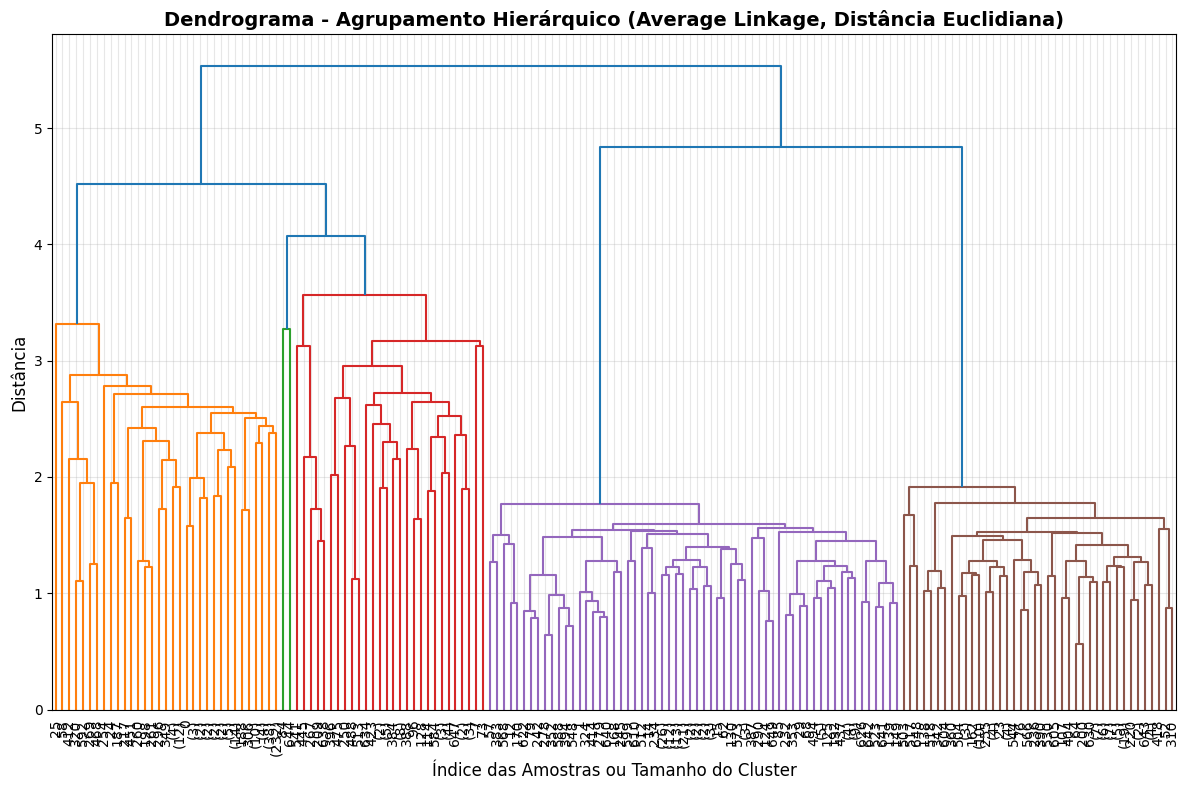

Dendrograma gerado com sucesso!
Análise visual: Observe onde há grandes 'saltos' na altura do dendrograma
Esses pontos indicam bons números de clusters para corte.


In [6]:
# Construir dendrograma para visualizar a estrutura hierárquica
plt.figure(figsize=(12, 8))

# Calcular a matriz de linkage usando average linkage e distância euclidiana
linkage_matrix = linkage(X_scaled, method='average', metric='euclidean')

# Plotar o dendrograma
dendrogram(linkage_matrix, 
           truncate_mode='level',  # Truncar para níveis
           p=10,  # Mostrar apenas os últimos 10 níveis
           show_leaf_counts=True,
           leaf_font_size=10)

plt.title('Dendrograma - Agrupamento Hierárquico (Average Linkage, Distância Euclidiana)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Índice das Amostras ou Tamanho do Cluster', fontsize=12)
plt.ylabel('Distância', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Dendrograma gerado com sucesso!")
print("Análise visual: Observe onde há grandes 'saltos' na altura do dendrograma")
print("Esses pontos indicam bons números de clusters para corte.")

=== Análise do Coeficiente Silhueta ===
Calculando coeficiente silhueta para diferentes números de clusters...
N° Clusters:  2 | Coeficiente Silhueta: 0.4703
N° Clusters:  3 | Coeficiente Silhueta: 0.5449
N° Clusters:  4 | Coeficiente Silhueta: 0.5527
N° Clusters:  5 | Coeficiente Silhueta: 0.5417
N° Clusters:  6 | Coeficiente Silhueta: 0.5316
N° Clusters:  7 | Coeficiente Silhueta: 0.4320
N° Clusters:  8 | Coeficiente Silhueta: 0.4282
N° Clusters:  9 | Coeficiente Silhueta: 0.4240
N° Clusters: 10 | Coeficiente Silhueta: 0.4218

=== Resultado da Análise ===
Número ótimo de clusters: 4
Melhor coeficiente silhueta: 0.5527


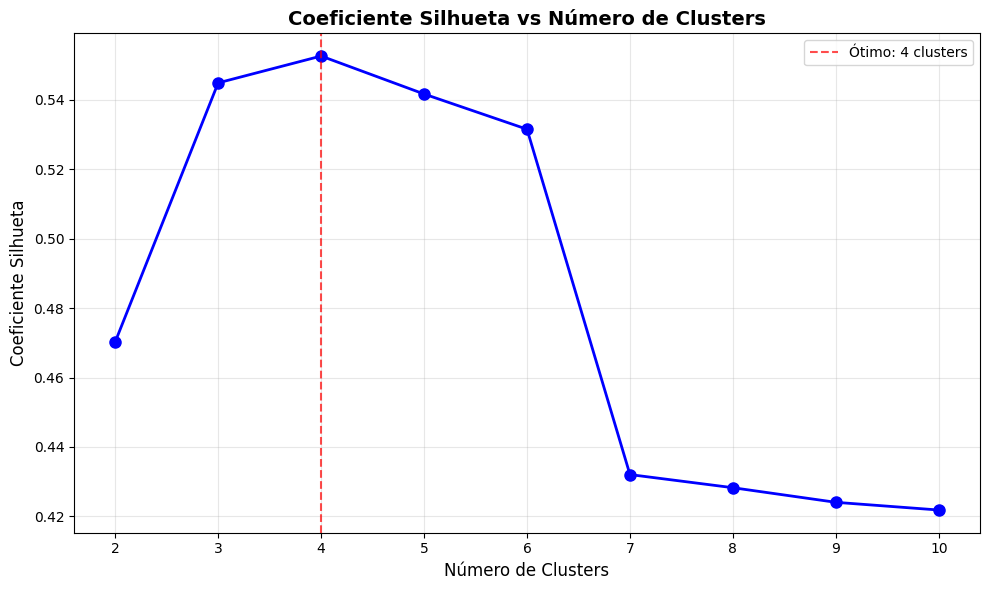


📊 Interpretação do Coeficiente Silhueta:
• Valores próximos de 1: Clusters bem definidos e separados
• Valores próximos de 0: Clusters sobrepostos
• Valores negativos: Amostras podem estar no cluster errado


In [7]:
# Calcular coeficiente silhueta para diferentes números de clusters
silhouette_scores = []
cluster_range = range(2, 11)  # Testar de 2 a 10 clusters

print("=== Análise do Coeficiente Silhueta ===")
print("Calculando coeficiente silhueta para diferentes números de clusters...")

for n_clusters in cluster_range:
    # Criar modelo de agrupamento hierárquico
    hierarchical = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage='average',
        metric='euclidean'
    )
    
    # Ajustar o modelo e obter labels
    cluster_labels = hierarchical.fit_predict(X_scaled)
    
    # Calcular coeficiente silhueta
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
    print(f"N° Clusters: {n_clusters:2d} | Coeficiente Silhueta: {silhouette_avg:.4f}")

# Encontrar o número ótimo de clusters
optimal_clusters = cluster_range[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)

print(f"\n=== Resultado da Análise ===")
print(f"Número ótimo de clusters: {optimal_clusters}")
print(f"Melhor coeficiente silhueta: {best_silhouette:.4f}")

# Plotar gráfico do coeficiente silhueta
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=optimal_clusters, color='red', linestyle='--', alpha=0.7, 
            label=f'Ótimo: {optimal_clusters} clusters')
plt.xlabel('Número de Clusters', fontsize=12)
plt.ylabel('Coeficiente Silhueta', fontsize=12)
plt.title('Coeficiente Silhueta vs Número de Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\n📊 Interpretação do Coeficiente Silhueta:")
print("• Valores próximos de 1: Clusters bem definidos e separados")
print("• Valores próximos de 0: Clusters sobrepostos")
print("• Valores negativos: Amostras podem estar no cluster errado")

=== Modelo Final de Agrupamento Hierárquico ===
Modelo criado com 4 clusters
Coeficiente Silhueta final: 0.5527

=== Análise dos Clusters ===
Distribuição de amostras por cluster:
Cluster 0: 50 amostras (7.7%)
Cluster 1: 350 amostras (53.8%)
Cluster 2: 150 amostras (23.1%)
Cluster 3: 100 amostras (15.4%)

=== Estatísticas por Cluster ===
             x0              x1              x2              x3          \
           mean     std    mean     std    mean     std    mean     std   
Cluster                                                                   
0        7.9007  3.1415 -6.5430  2.8045  4.7931  2.8303  1.1507  2.6567   
1        5.1498  2.6477 -6.8688  2.5000  2.4053  2.4732 -8.2668  2.4786   
2       -5.5431  1.6557  5.1864  1.4949 -3.1900  1.5963  3.3646  1.4911   
3       -6.3269  1.6565 -2.5385  1.6585  4.7119  1.4590  4.7681  1.5734   

             x4              x5              x6              x7          \
           mean     std    mean     std    mean     std    

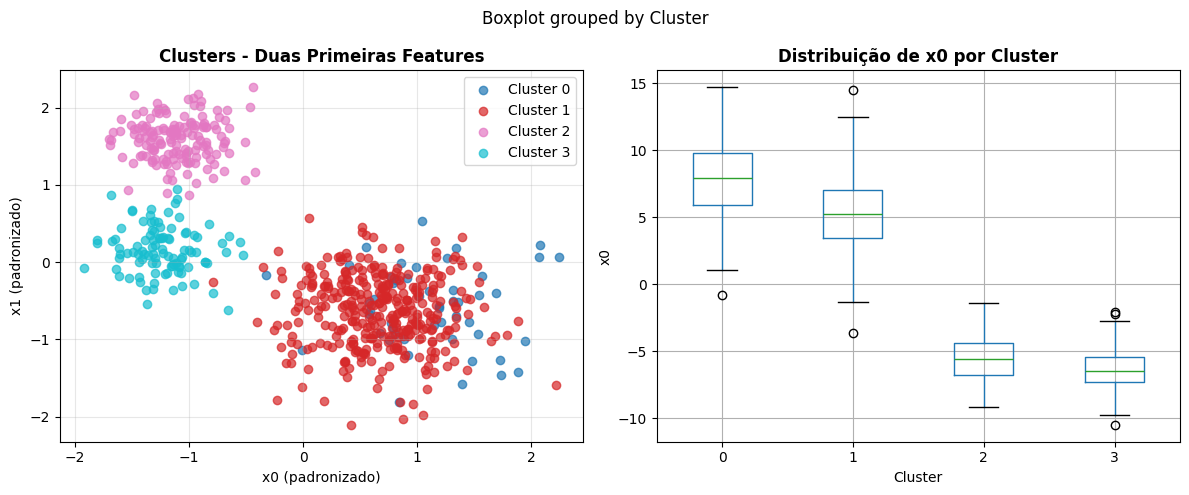


✅ Agrupamento hierárquico concluído com sucesso!
📈 Método: Average Linkage com Distância Euclidiana
🎯 Número ótimo de clusters: 4
📊 Coeficiente Silhueta: 0.5527


In [8]:
# Criar modelo final com o número ótimo de clusters
print("=== Modelo Final de Agrupamento Hierárquico ===")

# Criar e ajustar o modelo final
final_model = AgglomerativeClustering(
    n_clusters=optimal_clusters,
    linkage='average',
    metric='euclidean'
)

# Obter os clusters finais
final_labels = final_model.fit_predict(X_scaled)

# Adicionar os clusters ao DataFrame original
df_clustered = df.copy()
df_clustered['Cluster'] = final_labels

print(f"Modelo criado com {optimal_clusters} clusters")
print(f"Coeficiente Silhueta final: {best_silhouette:.4f}")

# Análise dos clusters
print("\n=== Análise dos Clusters ===")
cluster_counts = pd.Series(final_labels).value_counts().sort_index()
print("Distribuição de amostras por cluster:")
for cluster, count in cluster_counts.items():
    percentage = (count / len(df_clustered)) * 100
    print(f"Cluster {cluster}: {count} amostras ({percentage:.1f}%)")

# Estatísticas descritivas por cluster
print("\n=== Estatísticas por Cluster ===")
cluster_stats = df_clustered.groupby('Cluster').agg({
    col: ['mean', 'std'] for col in X.columns
}).round(4)

print(cluster_stats)

# Visualização dos primeiros clusters (se houver pelo menos 2 features numéricas)
if len(X.columns) >= 2:
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Scatter plot dos dois primeiros features
    plt.subplot(1, 2, 1)
    colors = plt.cm.tab10(np.linspace(0, 1, optimal_clusters))
    
    for i in range(optimal_clusters):
        mask = final_labels == i
        plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1], 
                   c=[colors[i]], label=f'Cluster {i}', alpha=0.7)
    
    plt.xlabel(f'{X.columns[0]} (padronizado)', fontsize=10)
    plt.ylabel(f'{X.columns[1]} (padronizado)', fontsize=10)
    plt.title('Clusters - Duas Primeiras Features', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Boxplot da primeira feature por cluster
    plt.subplot(1, 2, 2)
    df_clustered.boxplot(column=X.columns[0], by='Cluster', ax=plt.gca())
    plt.title(f'Distribuição de {X.columns[0]} por Cluster', fontsize=12, fontweight='bold')
    plt.xlabel('Cluster')
    plt.ylabel(X.columns[0])
    
    plt.tight_layout()
    plt.show()

print(f"\n✅ Agrupamento hierárquico concluído com sucesso!")
print(f"📈 Método: Average Linkage com Distância Euclidiana")
print(f"🎯 Número ótimo de clusters: {optimal_clusters}")
print(f"📊 Coeficiente Silhueta: {best_silhouette:.4f}")